In [2]:
import os
print(os.listdir('../data/shapefiles'))

['INDIAN-SHAPEFILES-master']


In [2]:
import pyreadstat

# Load ONLY metadata - no actual data loaded, takes seconds
_, meta = pyreadstat.read_dta(
    'C:/maternal_health_project/data/IAIR7EFL.DTA',
    metadataonly=True
)

print("Total columns in dataset:", len(meta.column_names))
print("\nAll column names:")
for i, col in enumerate(meta.column_names):
    print(f"{i+1:4}. {col}")

Total columns in dataset: 5972

All column names:
   1. caseid
   2. v000
   3. v001
   4. v002
   5. v003
   6. v004
   7. v005
   8. v006
   9. v007
  10. v008
  11. v008a
  12. v009
  13. v010
  14. v011
  15. v012
  16. v013
  17. v014
  18. v015
  19. v016
  20. v017
  21. v018
  22. v019
  23. v019a
  24. v020
  25. v021
  26. v022
  27. v023
  28. v024
  29. v025
  30. v026
  31. v027
  32. v028
  33. v029
  34. v030
  35. v031
  36. v032
  37. v034
  38. v040
  39. v042
  40. v044
  41. v045a
  42. v045b
  43. v045c
  44. v046
  45. v101
  46. v102
  47. v103
  48. v104
  49. v105
  50. v105a
  51. v106
  52. v107
  53. v113
  54. v115
  55. v116
  56. v119
  57. v120
  58. v121
  59. v122
  60. v123
  61. v124
  62. v125
  63. v127
  64. v128
  65. v129
  66. v130
  67. v131
  68. v133
  69. v134
  70. v135
  71. v136
  72. v137
  73. v138
  74. v139
  75. v140
  76. v141
  77. v149
  78. v150
  79. v151
  80. v152
  81. v153
  82. awfactt
  83. awfactu
  84. awfactr
  85. awf

In [3]:
# We'll fill these after seeing the column list
columns_we_need = [
    'v012',   # age
    'v190',   # wealth index
    # ... etc (I'll give you the full list after Step 1)
]

df, meta = pyreadstat.read_dta(
    'C:/maternal_health_project/data/IAIR7EFL.DTA',
    usecols=columns_we_need
)

print("Shape:", df.shape)

Shape: (724115, 2)


In [4]:
import pyreadstat
import pandas as pd

# Exactly 28 columns we need for the project
columns_needed = [
    # --- IDENTIFICATION ---
    'v024',    # State
    'v025',    # Rural/Urban
    'v001',    # Cluster number (district proxy)

    # --- CLINICAL FEATURES ---
    'v012',    # Woman's current age
    'v201',    # Total children ever born
    'v213',    # Currently pregnant
    'v437',    # Weight in kg (BMI numerator)
    'v438',    # Height in cm (BMI denominator)
    'v445',    # BMI
    'm14_1',   # Number of ANC visits (most recent birth)
    'm15_1',   # Place of delivery
    'm17_1',   # Delivery by caesarean section
    'v453',    # Haemoglobin level (anaemia indicator)
    'v454',    # Currently anaemic
    's116',    # Blood pressure measured

    # --- SOCIOECONOMIC FEATURES (SDoH) ---
    'v106',    # Woman's education level
    'v130',    # Religion
    'v131',    # Ethnicity / Caste (SC/ST/OBC/Other)
    'v190',    # Wealth index (1=poorest to 5=richest)
    'v113',    # Source of drinking water
    'v116',    # Type of toilet facility
    'v119',    # Electricity
    'v149',    # Educational attainment
    'v157',    # Reads newspaper
    'v158',    # Watches television
    'v159',    # Listens to radio

    # --- TARGET VARIABLE COMPONENTS ---
    'v228',    # Ever had a terminated pregnancy
    'b5_01',   # Child is alive (most recent birth - outcome proxy)
]

print("Loading only 28 selected columns... (should take 1-2 mins)")

df, meta = pyreadstat.read_dta(
    'C:/maternal_health_project/data/IAIR7EFL.DTA',
    usecols=columns_needed
)

print("✅ Loaded successfully!")
print(f"Shape: {df.shape}")
print(f"\nColumn names: {df.columns.tolist()}")
print(f"\nFirst 3 rows:")
print(df.head(3))

Loading only 28 selected columns... (should take 1-2 mins)
✅ Loaded successfully!
Shape: (724115, 28)

Column names: ['v001', 'v012', 'v024', 'v025', 'v106', 'v113', 'v116', 'v119', 'v130', 'v131', 'v149', 'v157', 'v158', 'v159', 'v190', 'b5_01', 'v201', 'v213', 'v228', 'm14_1', 'm15_1', 'm17_1', 'v437', 'v438', 'v445', 'v453', 'v454', 's116']

First 3 rows:
   v001  v012  v024  v025  v106  v113 v116  v119  v130  v131  ...  v228  \
0   113    22     1     2     3    14   12     1     2   991  ...     0   
1   113    19     1     2     2    14   12     1     2   991  ...     0   
2   113    38     1     2     1    14   44     1     2   991  ...     0   

   m14_1  m15_1  m17_1  v437  v438  v445  v453  v454 s116  
0    NaN    NaN    NaN   353  1427  1734   117     0    4  
1    NaN    NaN    NaN   310  1397  1586    93     0    4  
2    NaN    NaN    NaN   755  1479  3449    94     0    4  

[3 rows x 28 columns]


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyreadstat
import warnings
warnings.filterwarnings('ignore')

columns_needed = [
    'v001','v012','v024','v025','v106','v113','v116',
    'v119','v130','v131','v149','v157','v158','v159',
    'v190','b5_01','v201','v213','v228','m14_1','m15_1',
    'm17_1','v437','v438','v445','v453','v454','s116'
]

df, meta = pyreadstat.read_dta(
    'C:/maternal_health_project/data/IAIR7EFL.DTA',
    usecols=columns_needed
)
print(f"✅ Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(df.head(3))

✅ Loaded: 724,115 rows × 28 columns
   v001  v012  v024  v025  v106  v113 v116  v119  v130  v131  ...  v228  \
0   113    22     1     2     3    14   12     1     2   991  ...     0   
1   113    19     1     2     2    14   12     1     2   991  ...     0   
2   113    38     1     2     1    14   44     1     2   991  ...     0   

   m14_1  m15_1  m17_1  v437  v438  v445  v453  v454 s116  
0    NaN    NaN    NaN   353  1427  1734   117     0    4  
1    NaN    NaN    NaN   310  1397  1586    93     0    4  
2    NaN    NaN    NaN   755  1479  3449    94     0    4  

[3 rows x 28 columns]


       Missing Count  Missing %
m15_1         547272      75.58
m14_1         547272      75.58
m17_1         547272      75.58
b5_01         230096      31.78
s116           34661       4.79
v445           23957       3.31
v453           21576       2.98
v437             363       0.05
v438             384       0.05
v116               1       0.00


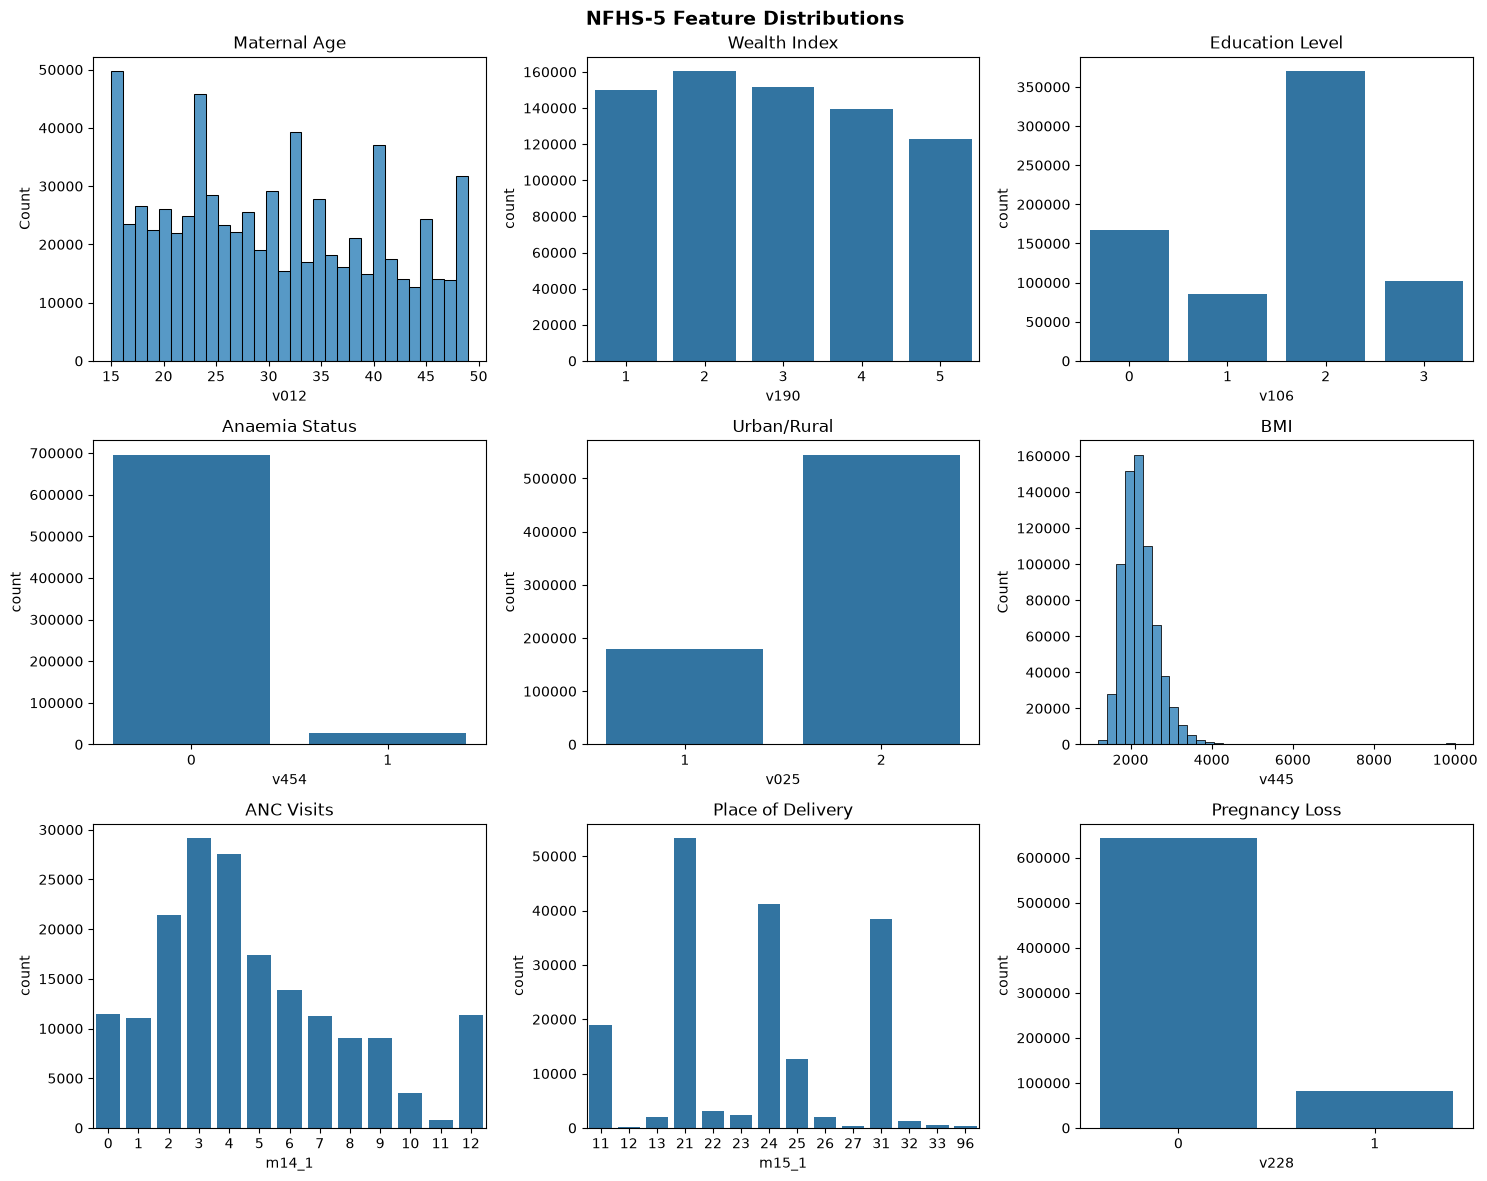

✅ EDA plots saved.


In [2]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count':missing,'Missing %':missing_pct})
print(missing_df[missing_df['Missing Count']>0].sort_values('Missing %',ascending=False))

fig, axes = plt.subplots(3, 3, figsize=(15,12))
fig.suptitle('NFHS-5 Feature Distributions', fontsize=14, fontweight='bold')
sns.histplot(df['v012'].dropna(), bins=30, ax=axes[0,0]); axes[0,0].set_title("Maternal Age")
sns.countplot(x=df['v190'].dropna(), ax=axes[0,1]); axes[0,1].set_title("Wealth Index")
sns.countplot(x=df['v106'].dropna(), ax=axes[0,2]); axes[0,2].set_title("Education Level")
sns.countplot(x=df['v454'].dropna(), ax=axes[1,0]); axes[1,0].set_title("Anaemia Status")
sns.countplot(x=df['v025'].dropna(), ax=axes[1,1]); axes[1,1].set_title("Urban/Rural")
sns.histplot(df['v445'].dropna(), bins=40, ax=axes[1,2]); axes[1,2].set_title("BMI")
sns.countplot(x=df['m14_1'].dropna().clip(0,12), ax=axes[2,0]); axes[2,0].set_title("ANC Visits")
sns.countplot(x=df['m15_1'].dropna(), ax=axes[2,1]); axes[2,1].set_title("Place of Delivery")
sns.countplot(x=df['v228'].dropna(), ax=axes[2,2]); axes[2,2].set_title("Pregnancy Loss")
plt.tight_layout()
plt.savefig('C:/maternal_health_project/figures/eda_plots/distributions.png', dpi=150)
plt.show()
print("✅ EDA plots saved.")

In [3]:
state_summary = df.groupby('v024').agg(
    total_women=('v012','count'),
    avg_age=('v012','mean'),
    avg_anc=('m14_1','mean'),
    anaemia_rate=('v454', lambda x: (x>0).mean()*100),
    avg_wealth=('v190','mean'),
    avg_education=('v106','mean')
).round(2)
print(state_summary.sort_values('total_women',ascending=False).head(10))
state_summary.to_csv('C:/maternal_health_project/outputs/state_summary.csv')
print("✅ State summary saved.")

      total_women  avg_age   avg_anc  anaemia_rate  avg_wealth  avg_education
v024                                                                         
9           93124    28.97  3.746674          4.24        2.74           1.46
23          48410    29.95  5.051795          3.90        2.54           1.40
8           42990    29.39   4.33478          3.86        3.12           1.34
10          42483    28.55  3.082745          6.28        2.08           1.18
18          34979    30.42   4.86255          3.97        2.08           1.57
27          33755    31.31  9.406743          3.21        3.27           1.78
24          33343    30.89    7.6033          3.45        3.21           1.54
29          30455    31.34  5.857098          3.26        3.17           1.62
22          28468    29.96  5.996016          3.84        2.37           1.42
21          27971    30.86  6.512533          3.36        2.25           1.47
✅ State summary saved.
